# Projection Top-Down guidée (masque sémantique 1×1)

Objectif : **marier l'abstraction sémantique des couches profondes (C8) avec la résolution spatiale de C1**.

1. **Sélection** : un neurone d'ancrage actif en couche profonde
2. **Back-propagation top-down** : propagation du signal vers le bas via les skip-connections et les tubes Physarum
3. **Filtre spatial** : C1 agit comme un filtre haute résolution (chaque patch est marqué s'il reçoit le rétro-signal)
4. **Masque final** : masque binaire 1×1 où l'objet est unifié

## 0. Imports + chargement

In [1]:
# Projection Top-Down guidée : masque sémantique 1×1
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as IImg, display
from recherche_agi import (HierarchicalCOCO, color_texture_features,
                           topdown_projection, project_to_pixels,
                           backprop_topdown)

d = np.load('../data/coco_stuff/features_val.npz')
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé : {len(features)} classes, dim {d_in}")

Chargé : 171 classes, dim 35


## 1. Entraînement hiérarchique (avec skip connections)

In [2]:
model = HierarchicalCOCO(d_in=d_in, n_init=10, novelty_threshold=0.7, max_neurons=2000,
                         surprise_plateau=0.002, plateau_window=200, min_neurons_before_spawn=30)
for ci, cls in enumerate(sorted(features.keys())[:40]):
    X = features[cls][:80]
    gw = int(np.ceil(np.sqrt(len(X)))); gh = int(np.ceil(len(X)/gw))
    model.step_image(X, np.full(len(X), cls), gh, gw)
s = model.summary()
layers = model.layers + [model.layer]
print(f"Modèle : {s['layers']} couches, tailles {s['layer_sizes']}, {s['skips']['n_connections']} skip connections")

Modèle : 8 couches, tailles [36, 32, 48, 35, 38, 44, 31, 20], 500 skip connections


## 2. Projection top-down sur une vraie image → masque 1×1

C:\Users\henry\Desktop\workspace\recherche-agi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


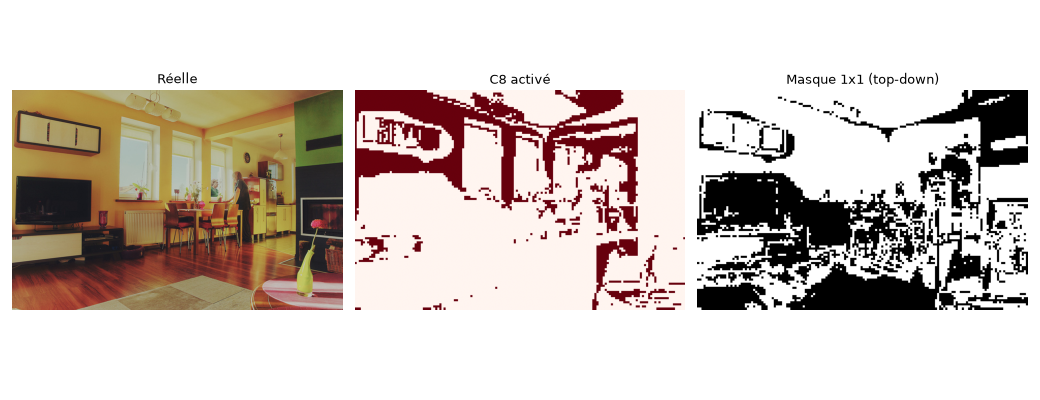

exemple 1: neurone C8 #7, masque 10009/16960 patches


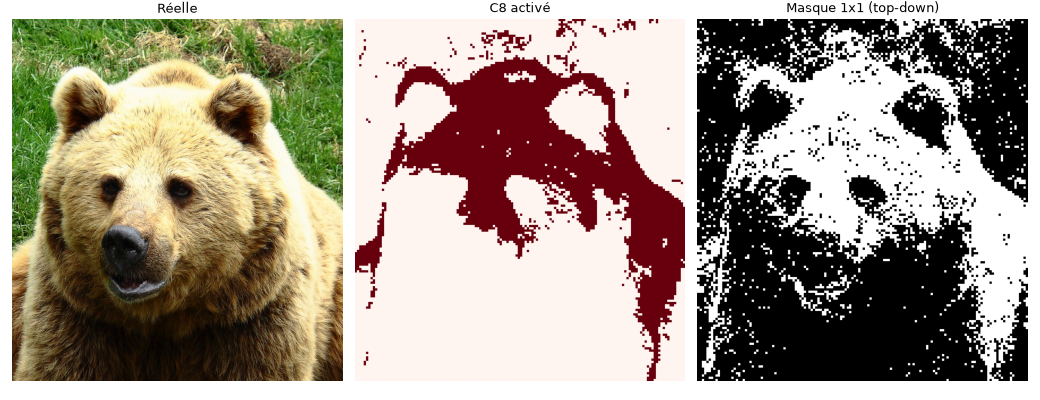

exemple 2: neurone C8 #2, masque 8989/23360 patches


In [3]:
from datasets import load_dataset
ds = load_dataset('shunk031/cocostuff','stuff-thing',split='validation',streaming=True,trust_remote_code=True)

PS = 4
n_layers = model.summary()['layers']
target_depth = n_layers - 1   # couche profonde
N_IMG = 2

for n, x in enumerate(ds):
    if n >= N_IMG: break
    img = np.array(x['image'])
    H, Wimg = img.shape[0]-img.shape[0]%PS, img.shape[1]-img.shape[1]%PS
    img_c = img[:H,:Wimg]
    gh, gw = H//PS, Wimg//PS
    feats = np.zeros((gh*gw, d_in))
    for i in range(0, H, PS):
        for j in range(0, Wimg, PS):
            feats[(i//PS)*gw+(j//PS)] = color_texture_features(img_c[i:i+PS, j:j+PS])
    zn = feats/(np.linalg.norm(feats,axis=1,keepdims=True)+1e-8)
    deep_acts = zn @ layers[target_depth].W.T
    target = int(np.bincount(np.argmax(deep_acts,axis=1)).argmax())
    mask_patches = topdown_projection(model, zn, target_depth, target)
    mask_1x1 = project_to_pixels(mask_patches, gh, gw, PS)
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    axes[0].imshow(img); axes[0].set_title('Réelle'); axes[0].axis('off')
    c8_mask = np.zeros((gh, gw))
    c8_mask[deep_acts.argmax(axis=1).reshape(gh,gw)==target] = 1
    axes[1].imshow(np.kron(c8_mask, np.ones((PS,PS))), cmap='Reds')
    axes[1].set_title('C8 activé'); axes[1].axis('off')
    axes[2].imshow(mask_1x1, cmap='gray')
    axes[2].set_title('Masque 1x1 (top-down)'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'figs/coco_topdown_ex{n+1}.png', dpi=80); plt.close()
    display(IImg(f'figs/coco_topdown_ex{n+1}.png'))
    print(f'exemple {n+1}: neurone C8 #{target}, masque {int(mask_patches.sum())}/{len(mask_patches)} patches')

## 3. Analyse

In [4]:
print("=== ANALYSE : PROJECTION TOP-DOWN GUIDÉE ===")
print("1. Le neurone C8 (couche profonde) code une catégorie sémantique.")
print("2. La back-propagation via skip connections renvoie le signal à C1.")
print("3. C1 filtre spatialement -> masque 1x1 de l'objet.")
print("4. Le masque est unifié à l'échelle du pixel (0/1).")

=== ANALYSE : PROJECTION TOP-DOWN GUIDÉE ===
1. Le neurone C8 (couche profonde) code une catégorie sémantique.
2. La back-propagation via skip connections renvoie le signal à C1.
3. C1 filtre spatialement -> masque 1x1 de l'objet.
4. Le masque est unifié à l'échelle du pixel (0/1).
